# Cityscapes Dataset Exploration

Quick notebook to inspect splits, file counts, and visualize sample images + annotations.

In [2]:
import os
import glob
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [3]:
# Adjust this path if needed
cityscapes_path = "datasets/cityscapes"
gt_dir = os.path.join(cityscapes_path, 'gtFine')
img_dir = os.path.join(cityscapes_path, 'leftImg8bit_trainvaltest')
print('gtFine exists:', os.path.isdir(gt_dir))
print('leftImg8bit_trainvaltest exists:', os.path.isdir(img_dir))

gtFine exists: True
leftImg8bit_trainvaltest exists: True


In [12]:
# List available splits and the cities
for folder in ['train', 'val', 'test']:
    p = os.path.join(gt_dir, folder)
    if os.path.isdir(p):
        cities = sorted(os.listdir(p))
        print(f'{folder}: {len(cities)} cities, sample:', cities[:])
    else:
        print(f'{folder}: not present')
        
## label name example: gtFine_trainvaltest/gtFine/val/frankfurt/frankfurt_000000_000294_gtFine_labelIds.png
## image name example: leftImg8bit_trainvaltest/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png

train: 18 cities, sample: ['aachen', 'bochum', 'bremen', 'cologne', 'darmstadt', 'dusseldorf', 'erfurt', 'hamburg', 'hanover', 'jena', 'krefeld', 'monchengladbach', 'strasbourg', 'stuttgart', 'tubingen', 'ulm', 'weimar', 'zurich']
val: 3 cities, sample: ['frankfurt', 'lindau', 'munster']
test: 6 cities, sample: ['berlin', 'bielefeld', 'bonn', 'leverkusen', 'mainz', 'munich']


In [5]:
# Count files by extension under gtFine and images
def count_files(root, pattern='**/*'):
    return sum(1 for _ in Path(root).rglob(pattern) if _.is_file())

print('gtFine total files:', count_files(gt_dir))
print('leftImg8bit_trainvaltest total files:', count_files(img_dir))

gtFine total files: 20000
leftImg8bit_trainvaltest total files: 5002


Image: datasets/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/train/dusseldorf/dusseldorf_000029_000019_leftImg8bit.png
GT: datasets/cityscapes/gtFine/train/dusseldorf/dusseldorf_000029_000019_gtFine_labelIds.png


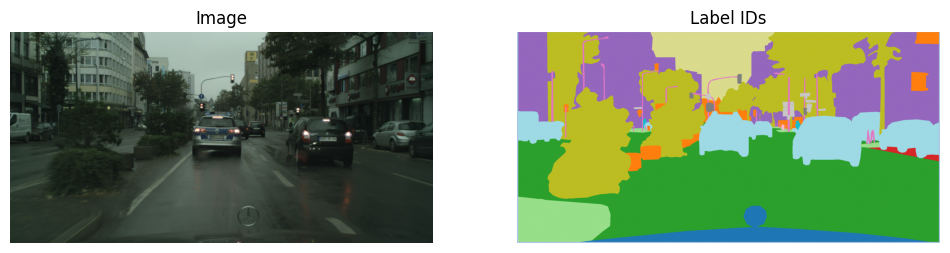

In [6]:
# Show a sample image and its corresponding labelIds annotation
def find_corresponding_gt(image_path):
    # image_path example:
    # .../leftImg8bit_trainvaltest/leftImg8bit/train/weimar/weimar_000072_000019_leftImg8bit.png
    path = Path(image_path)
    parts = path.parts

    try:
        idx = parts.index('leftImg8bit_trainvaltest')
        rel_parts = parts[idx + 1 :]
        if rel_parts and rel_parts[0] == 'leftImg8bit':
            rel_parts = rel_parts[1:]
    except ValueError:
        try:
            idx = parts.index('leftImg8bit')
            rel_parts = parts[idx + 1 :]
        except ValueError:
            return None

    if len(rel_parts) < 3:
        return None

    split = rel_parts[0]
    city = rel_parts[1]
    image_name = rel_parts[-1]
    base_name = image_name.replace('_leftImg8bit.png', '')
    search_dir = Path(gt_dir) / split / city

    fp = search_dir / f'{base_name}_gtFine_labelIds.png'
    if fp.exists():
        return str(fp)

    for fp in search_dir.glob(base_name + '*'):
        if fp.is_file():
            return str(fp)

    return None


def show_sample(split='train'):
    img_search = Path(img_dir) / 'leftImg8bit' / split
    cities = [d for d in img_search.iterdir() if d.is_dir()]
    if not cities:
        print('No cities found in', img_search)
        return
    city = random.choice(cities)
    imgs = list(city.glob('*_leftImg8bit.png'))
    if not imgs:
        print('No images in', city)
        return
    img_path = str(random.choice(imgs))
    gt_path = find_corresponding_gt(img_path)
    print('Image:', img_path)
    print('GT:', gt_path)
    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(img)
    plt.axis('off')
    if gt_path is not None:
        gt = Image.open(gt_path)
        plt.subplot(1, 2, 2)
        plt.title('Label IDs')
        plt.imshow(gt, cmap='tab20')
        plt.axis('off')
    plt.show()

# show one sample
show_sample('train')

In [7]:
import sys
sys.path.append("./DeepLabV3Plus-Pytorch")

import os
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms as T
import matplotlib.pyplot as plt

import network
import utils
from datasets import VOCSegmentation, Cityscapes

In [8]:

def load_deeplab_model(
    ckpt_path,
    dataset="cityscapes",
    model_name="deeplabv3plus_mobilenet",
    output_stride=16,
    gpu_id="0",
    separable_conv=False,
):
    if dataset.lower() == "voc":
        num_classes = 21
        decode_fn = VOCSegmentation.decode_target
    elif dataset.lower() == "cityscapes":
        num_classes = 19
        decode_fn = Cityscapes.decode_target
    else:
        raise ValueError("dataset must be 'voc' or 'cityscapes'")

    os.environ["CUDA_VISIBLE_DEVICES"] = gpu_id
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = network.modeling.__dict__[model_name](
        num_classes=num_classes,
        output_stride=output_stride,
    )

    if separable_conv and "plus" in model_name:
        network.convert_to_separable_conv(model.classifier)

    utils.set_bn_momentum(model.backbone, momentum=0.01)

    checkpoint = torch.load(
        ckpt_path,
        map_location=torch.device("cpu"),
        weights_only=False,
    )

    model.load_state_dict(checkpoint["model_state"])
    model = nn.DataParallel(model)
    model.to(device)
    model.eval()

    print(f"Loaded model from: {ckpt_path}")
    print(f"Device: {device}")

    return model, decode_fn, device


def predict_image(
    model,
    image_path,
    decode_fn,
    device,
    crop_val=False,
    crop_size=513,
    save_path=None,
    show=True,
):
    if crop_val:
        transform = T.Compose([
            T.Resize(crop_size),
            T.CenterCrop(crop_size),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    else:
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).max(1)[1].cpu().numpy()[0]

    colorized_pred = decode_fn(pred).astype("uint8")
    colorized_pred = Image.fromarray(colorized_pred)

    if save_path is not None:
        colorized_pred.save(save_path)
        print(f"Saved prediction to: {save_path}")

    if show:
        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Input image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(colorized_pred)
        plt.title("DeepLabV3+ prediction")
        plt.axis("off")

        plt.show()

    return pred, colorized_pred

In [9]:
def predict_image(
    model,
    image_path,
    decode_fn,
    device,
    crop_val=False,
    crop_size=513,
):
    if crop_val:
        transform = T.Compose([
            T.Resize(crop_size),
            T.CenterCrop(crop_size),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    else:
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    image = Image.open(image_path).convert("RGB")

    gt_path = find_corresponding_gt(image_path)

    if gt_path is not None:
        gt = Image.open(gt_path)
    else:
        gt = None

    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).max(1)[1].cpu().numpy()[0]

    colorized_pred = decode_fn(pred).astype("uint8")

    plt.figure(figsize=(20, 7))

    # Input image
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(1, 3, 2)
    if gt is not None:
        plt.imshow(gt, cmap="tab20")
        plt.title("Ground Truth")
    else:
        plt.text(0.5, 0.5, "No GT found", ha='center', va='center')
        plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 3, 3)
    plt.imshow(colorized_pred)
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return pred

In [10]:
ckpt_path = "DeepLabV3Plus-Pytorch/checkpoints/best_deeplabv3plus_mobilenet_cityscapes_os16.pth"

model, decode_fn, device = load_deeplab_model(
    ckpt_path=ckpt_path,
    dataset="cityscapes",
    model_name="deeplabv3plus_mobilenet",
)

Loaded model from: DeepLabV3Plus-Pytorch/checkpoints/best_deeplabv3plus_mobilenet_cityscapes_os16.pth
Device: cuda


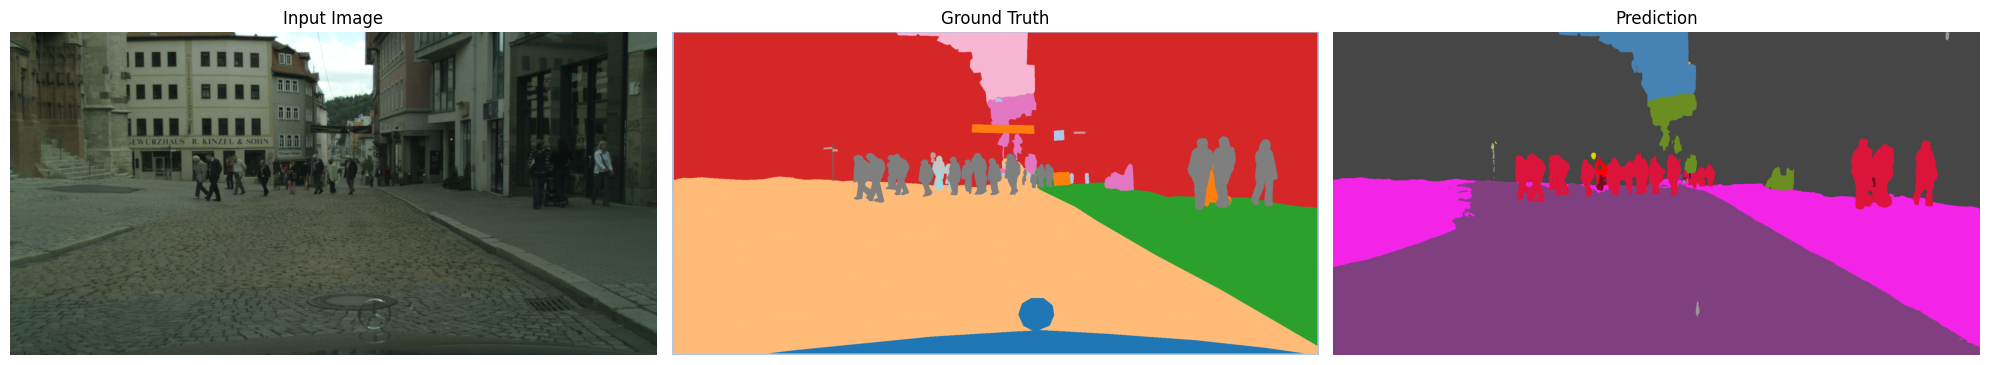

In [11]:
image_path = "/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/train/jena/jena_000082_000019_leftImg8bit.png"

pred = predict_image(
    model,
    image_path,
    decode_fn,
    device,
)

# Test Set evaluation 

In [14]:
def get_ordered_image_list(split='val', max_images=None):

    img_search = Path(img_dir) / 'leftImg8bit' / split
    if not img_search.exists():
        print(f'Split {split} not found at {img_search}')
        return []
    
    image_pairs = []
    cities = sorted([d for d in img_search.iterdir() if d.is_dir()])
    
    for city_dir in cities:
        # Sort images alphabetically within each city
        imgs = sorted(city_dir.glob('*_leftImg8bit.png'))
        for img_path in imgs:
            gt_path = find_corresponding_gt(str(img_path))
            if gt_path:
                image_pairs.append((str(img_path), gt_path))
                if max_images and len(image_pairs) >= max_images:
                    return image_pairs
    
    return image_pairs

# Test: get first 10 images from validation set
val_images = get_ordered_image_list('val', max_images=10)
print(f'Found {len(val_images)} validation images')
for i, (img_path, gt_path) in enumerate(val_images[:3]):
    print(f'  {i}: {Path(img_path).name}')

Found 10 validation images
  0: frankfurt_000000_000294_leftImg8bit.png
  1: frankfurt_000000_000576_leftImg8bit.png
  2: frankfurt_000000_001016_leftImg8bit.png


## Cityscapes Classes

Explore the 19 semantic segmentation classes in the Cityscapes dataset.


In [ ]:
# Get classes directly from Cityscapes implementation
from datasets import Cityscapes

# Extract training classes (train_id != 255) Used by DeepLabV3+ and evaluation
training_classes = [(c.name, c.id, c.train_id) for c in Cityscapes.classes 
                    if c.train_id != 255 and c.train_id != -1]

print(f"Total training classes: {len(training_classes)}")

# Display as a table
print(f"{'Train ID':<10} {'Class Name':<20} {'Original ID':<10}")
for name, orig_id, train_id in sorted(training_classes, key=lambda x: x[2]):
    print(f"{train_id:<10} {name:<20} {orig_id:<10}")

print("\n=== All Classes in Cityscapes (including void/ignore) ===")
print(f"Total classes: {len(Cityscapes.classes)}\n")
print(f"{'Orig ID':<10} {'Class Name':<25} {'Train ID':<10} {'Category':<15} {'Ignore':<8}")
print("-" * 70)
for c in Cityscapes.classes:
    ignore = "YES" if c.ignore_in_eval else "NO"
    print(f"{c.id:<10} {c.name:<25} {str(c.train_id):<10} {c.category:<15} {ignore:<8}")


Total training classes: 19
Train ID   Class Name           Original ID
----------------------------------------
0          road                 7         
1          sidewalk             8         
2          building             11        
3          wall                 12        
4          fence                13        
5          pole                 17        
6          traffic light        19        
7          traffic sign         20        
8          vegetation           21        
9          terrain              22        
10         sky                  23        
11         person               24        
12         rider                25        
13         car                  26        
14         truck                27        
15         bus                  28        
16         train                31        
17         motorcycle           32        
18         bicycle              33        

=== All Classes in Cityscapes (including void/ignore) ===
Total classe

## Metrics Evaluation

Compute segmentation metrics on a subset of validation images.


In [24]:
def compute_iou_metrics(model, image_pairs, decode_fn, device, crop_val=False, crop_size=513):
    """
    Compute IoU and accuracy metrics on a set of image-GT pairs.
    
    Returns:
        metrics: dict with 'pixel_acc', 'mean_acc', 'mIoU', 'class_iou'
        all_preds: list of predictions for visualization
    """
    from sklearn.metrics import confusion_matrix
    
    num_classes = 19  # Cityscapes
    confusion = np.zeros((num_classes, num_classes))
    all_preds = []
    
    if crop_val:
        transform = T.Compose([
            T.Resize(crop_size),
            T.CenterCrop(crop_size),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    
    print(f"Computing metrics on {len(image_pairs)} images...")
    for i, (img_path, gt_path) in enumerate(image_pairs):
        if i % 5 == 0:
            print(f"  {i}/{len(image_pairs)}")
        
        # Load and preprocess image
        image = Image.open(img_path).convert("RGB")
        x = transform(image).unsqueeze(0).to(device)
        
        # Get prediction
        with torch.no_grad():
            pred = model(x).max(1)[1].cpu().numpy()[0]
        
        # Load GT
        gt = np.array(Image.open(gt_path), dtype=np.int32)
        
        # Convert GT from original ID space (0-33) to train_id space (0-18)
        gt_train_id = np.zeros_like(gt, dtype=np.int32)
        for orig_id in range(len(Cityscapes.id_to_train_id)):
            mask = (gt == orig_id)
            gt_train_id[mask] = Cityscapes.id_to_train_id[orig_id]
        
        # Handle ignore index (train_id = 255 means ignore)
        valid_mask = gt_train_id != 255
        pred_valid = pred[valid_mask]
        gt_valid = gt_train_id[valid_mask]
        
        # Update confusion matrix (both pred and gt_valid are now in train_id space 0-18)
        confusion += confusion_matrix(gt_valid, pred_valid, labels=np.arange(num_classes))
        all_preds.append((pred, gt, image))
    
    # Compute metrics from confusion matrix
    iou_per_class = np.diag(confusion) / (confusion.sum(axis=1) + confusion.sum(axis=0) - np.diag(confusion) + 1e-10)
    pixel_acc = np.trace(confusion) / confusion.sum()
    mean_acc = np.mean(iou_per_class)
    mIoU = np.mean(iou_per_class)
    
    metrics = {
        'pixel_acc': pixel_acc,
        'mean_acc': mean_acc,
        'mIoU': mIoU,
        'class_iou': iou_per_class,
        'confusion_matrix': confusion
    }
    
    return metrics, all_preds

# Run on subset of val images
num_eval_images = 20
val_images_eval = get_ordered_image_list('val', max_images=num_eval_images)
metrics, predictions = compute_iou_metrics(model, val_images_eval, decode_fn, device)

print("\n=== Segmentation Metrics ===")
print(f"Pixel Accuracy: {metrics['pixel_acc']:.4f}")
print(f"Mean Accuracy: {metrics['mean_acc']:.4f}")
print(f"mIoU: {metrics['mIoU']:.4f}")


Computing metrics on 20 images...
  0/20
  5/20
  10/20
  15/20

=== Segmentation Metrics ===
Pixel Accuracy: 0.9508
Mean Accuracy: 0.7016
mIoU: 0.7016


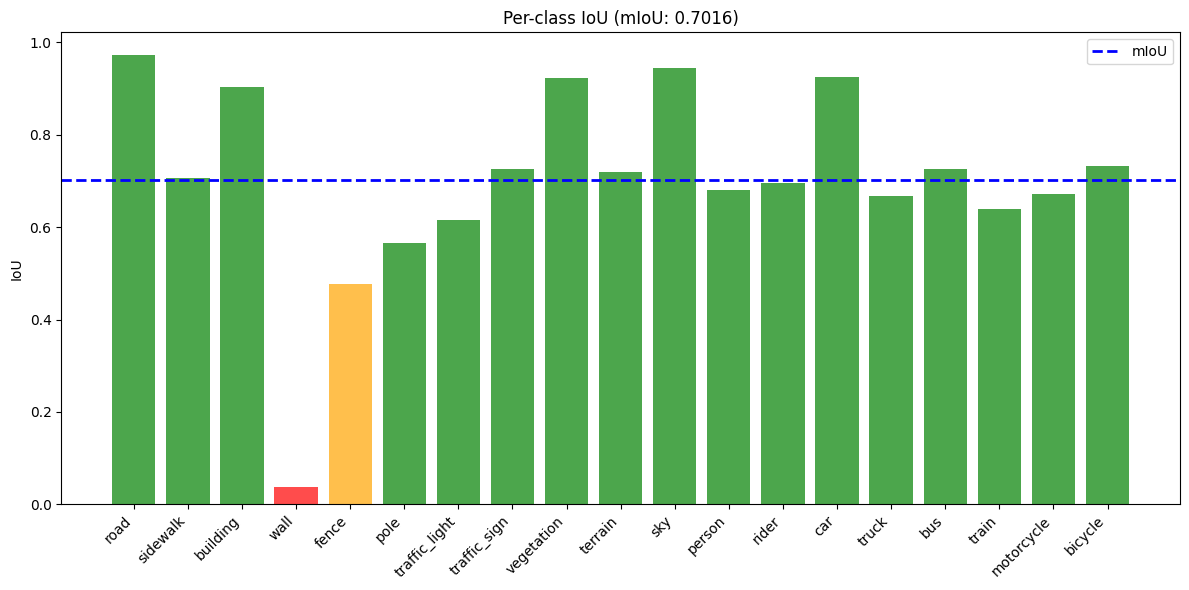


=== Per-Class IoU ===
road                : 0.9731
sidewalk            : 0.7074
building            : 0.9024
wall                : 0.0367
fence               : 0.4775
pole                : 0.5665
traffic_light       : 0.6150
traffic_sign        : 0.7258
vegetation          : 0.9230
terrain             : 0.7188
sky                 : 0.9447
person              : 0.6810
rider               : 0.6946
car                 : 0.9255
truck               : 0.6667
bus                 : 0.7266
train               : 0.6391
motorcycle          : 0.6727
bicycle             : 0.7332


In [25]:
# Cityscapes class names
CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole', 'traffic_light',
    'traffic_sign', 'vegetation', 'terrain', 'sky', 'person', 'rider', 'car',
    'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

# Visualize per-class IoU
fig, ax = plt.subplots(figsize=(12, 6))
class_iou = metrics['class_iou']
colors = ['green' if iou > 0.5 else 'orange' if iou > 0.3 else 'red' for iou in class_iou]
bars = ax.bar(range(len(CITYSCAPES_CLASSES)), class_iou, color=colors, alpha=0.7)
ax.set_xticks(range(len(CITYSCAPES_CLASSES)))
ax.set_xticklabels(CITYSCAPES_CLASSES, rotation=45, ha='right')
ax.set_ylabel('IoU')
ax.set_title(f'Per-class IoU (mIoU: {metrics["mIoU"]:.4f})')
ax.axhline(y=metrics['mIoU'], color='blue', linestyle='--', label='mIoU', linewidth=2)
ax.legend()
plt.tight_layout()
plt.show()

# Print per-class metrics
print("\n=== Per-Class IoU ===")
for cls_name, iou in zip(CITYSCAPES_CLASSES, class_iou):
    print(f"{cls_name:20s}: {iou:.4f}")


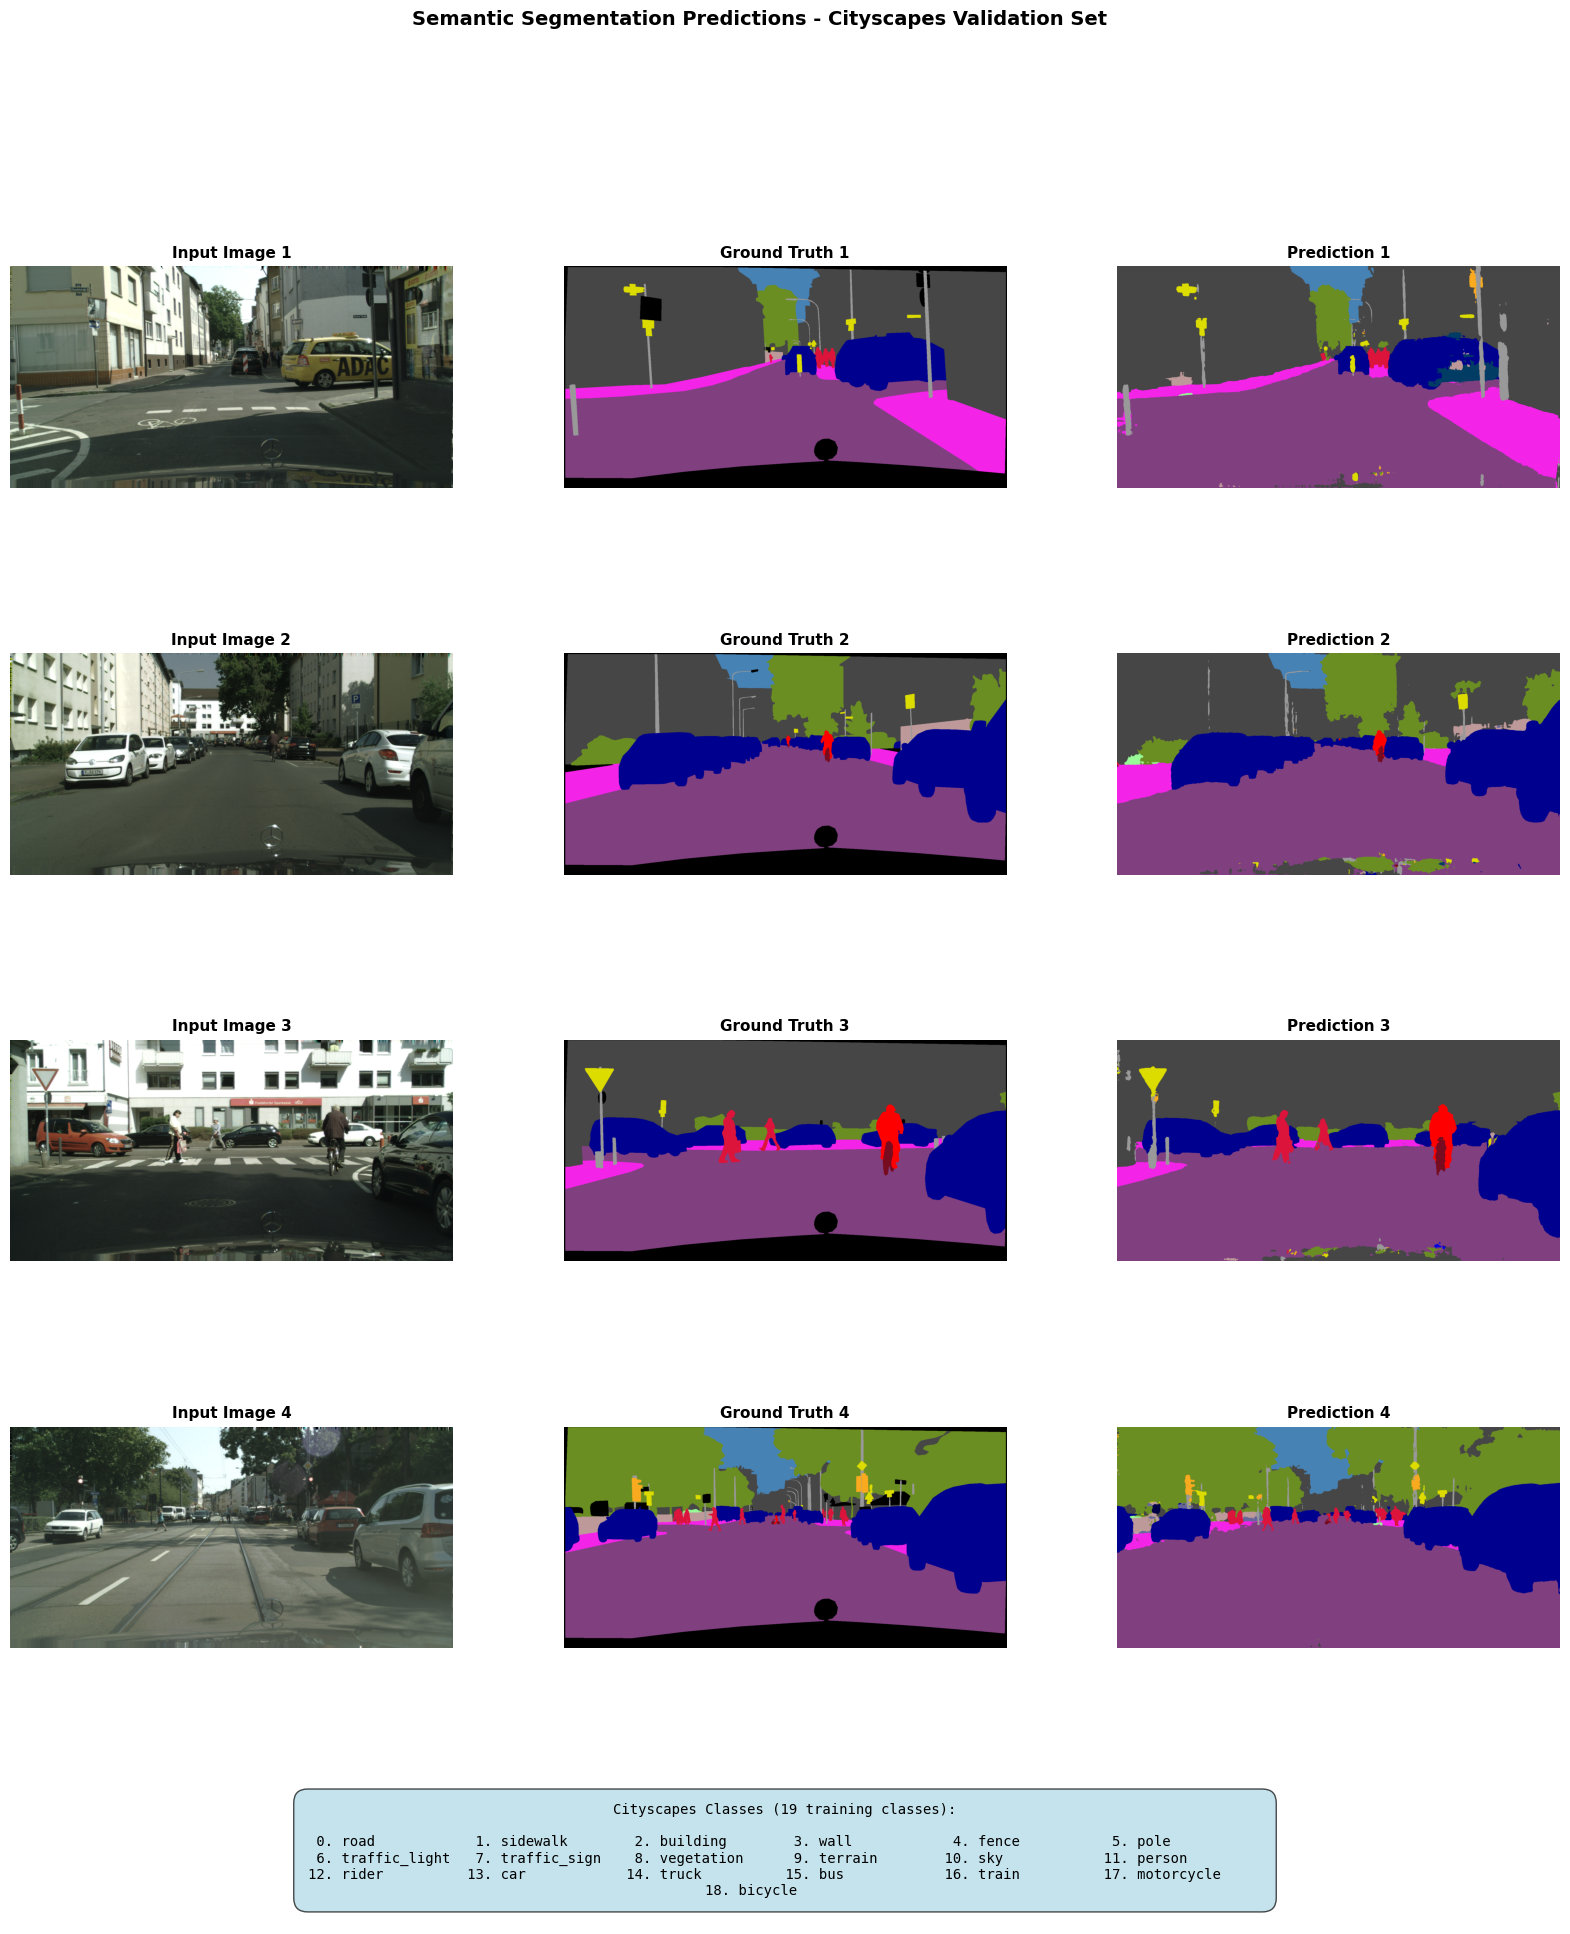


✓ Sample predictions with common class legend displayed


In [ ]:
# Show sample predictions vs ground truth with common class legend
num_samples = 4

# Create figure with space for legend at bottom
fig = plt.figure(figsize=(20, 5*num_samples + 2))
gs = fig.add_gridspec(num_samples + 1, 3, height_ratios=[1]*num_samples + [0.5], hspace=0.35, wspace=0.25)

for i in range(num_samples):
    if i < len(predictions):
        pred, gt, image = predictions[i]
        
        # Colorize predictions
        colorized_pred = decode_fn(pred).astype('uint8')
        
        # Convert GT to train_id format for visualization
        gt_train_id = np.zeros_like(gt, dtype=np.uint8)
        for orig_id in range(len(Cityscapes.id_to_train_id)):
            mask = (gt == orig_id)
            gt_train_id[mask] = Cityscapes.id_to_train_id[orig_id]
        gt_train_id[gt == 255] = 19
        gt_rgb = decode_fn(gt_train_id).astype('uint8')
        
        # Plot images
        ax0 = fig.add_subplot(gs[i, 0])
        ax0.imshow(image)
        ax0.set_title(f'Input Image {i+1}', fontsize=11, fontweight='bold')
        ax0.axis('off')
        
        ax1 = fig.add_subplot(gs[i, 1])
        ax1.imshow(gt_rgb)
        ax1.set_title(f'Ground Truth {i+1}', fontsize=11, fontweight='bold')
        ax1.axis('off')
        
        ax2 = fig.add_subplot(gs[i, 2])
        ax2.imshow(colorized_pred)
        ax2.set_title(f'Prediction {i+1}', fontsize=11, fontweight='bold')
        ax2.axis('off')

# Add common legend at the bottom
ax_legend = fig.add_subplot(gs[num_samples, :])
ax_legend.axis('off')

# Create a formatted legend with all classes
legend_text = "Cityscapes Classes (19 training classes):\n\n"
col_width = 6
for idx, class_name in enumerate(CITYSCAPES_CLASSES):
    if idx % col_width == 0 and idx > 0:
        legend_text += "\n"
    legend_text += f"{idx:2d}. {class_name:15s}"
    
ax_legend.text(0.5, 0.5, legend_text, transform=ax_legend.transAxes,
              fontsize=10, verticalalignment='center', horizontalalignment='center',
              family='monospace',
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7, pad=1))

plt.suptitle('Semantic Segmentation Predictions - Cityscapes Validation Set', 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()

print("\n✓ Sample predictions with common class legend displayed")
